/Users/sasha/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


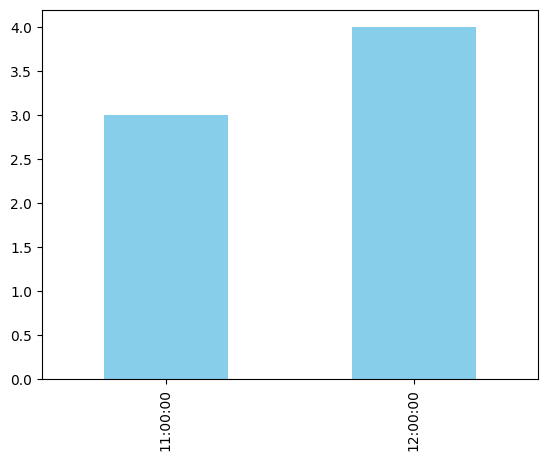

In [1]:
import requests, pandas as pd, matplotlib.pyplot as plt
from google.transit import gtfs_realtime_pb2

# 1. Fetch data & parse it directly
feed = gtfs_realtime_pb2.FeedMessage()
feed.ParseFromString(requests.get("https://api-endpoint.mta.info/Dataservice/mtagtfsfeeds/nyct%2Fgtfs-si").content)

# 2. Get hours, count them, and plot instantly
hours = [f.trip_update.trip.start_time[:2] + ":00:00" for f in feed.entity if f.HasField('trip_update')]
pd.Series(hours).value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.show()